# 02 — HNSW + Naive Post-Filtering

Build one HNSW index over the **full, unfiltered** corpus. For each query, run `knn_query(x, k=K, ef=HNSW_EF_SEARCH)` and drop results failing the filter afterward. This is the naive baseline that filtered-ANN methods exist to beat — recall should visibly collapse as selectivity drops, because a fixed top-K search over an unfiltered graph increasingly fails to surface even K filter-passing results. The 5%/10% synthetic filters are the ones that should show this most dramatically, so they are explicitly exercised below, not skipped.

This notebook is self-contained: it installs its own deps, loads data, builds embeddings, and writes its own results CSV. Only the methodology, config constants, seed, and corpus/query construction are shared verbatim across all 9 notebooks in this study.


## 1. Install

In [1]:
# Core install cell. Safe to re-run. Each notebook is independently runnable.
!pip install -q datasets sentence-transformers hnswlib scikit-learn pandas numpy tqdm


  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


## 2. Imports

In [2]:
import os, time, json, math
import numpy as np
import pandas as pd
import torch
from datasets import load_dataset
from sentence_transformers import SentenceTransformer
from tqdm.auto import tqdm

np.set_printoptions(suppress=True)
pd.set_option("display.max_columns", 50)

import hnswlib


## 3. Shared configuration

In [3]:
# ============================================================
# SHARED CONFIGURATION — identical across all 9 notebooks.
# Only DEBUG_MODE changes corpus/query size; everything else fixed.
# ============================================================
DEBUG_MODE   = True     # small N for correctness checks; set False for full run

N_CORPUS     = 60_000 if not DEBUG_MODE else 3_000
N_QUERIES    = 1_000  if not DEBUG_MODE else 100
K            = 10
SEED         = 42

EMBED_MODEL  = "sentence-transformers/all-MiniLM-L6-v2"   # 384-dim
HNSW_M               = 16
HNSW_EF_CONSTRUCTION = 200
HNSW_EF_SEARCH       = 100
HNSW_SPACE           = "cosine"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"DEBUG_MODE={DEBUG_MODE}  N_CORPUS={N_CORPUS}  N_QUERIES={N_QUERIES}  DEVICE={DEVICE}")


DEBUG_MODE=True  N_CORPUS=3000  N_QUERIES=100  DEVICE=cuda


## 4. Dataset — AG News corpus/query construction (shared, verbatim)

**Synthetic attributes, labeled explicitly:** `synthetic_tag` (uniform(0,1) per corpus doc) is used to carve the 10%/5% sub-selectivity filters out of a single-label 25% filter. `synthetic_range_attr` (uniform int in [0,10000)) has no semantic relationship to the article text and exists only so Notebook 08 can run a range-filtered experiment (AG News's label is categorical, not a range attribute).

In [4]:
# ============================================================
# DATASET — AG News. Hard-coded facts per spec:
#   4 classes, exactly balanced: 0=World, 1=Sports, 2=Business, 3=Sci/Tech
#   train: 120,000 rows (30,000/class). test: 7,600 rows (1,900/class).
# Corpus is drawn from train (subsampled to N_CORPUS), queries from test
# (subsampled to N_QUERIES), using SEED=42 for the subsample. This is why
# natural single-label filters have ~25% selectivity — not an arbitrary
# number, it follows directly from AG News's exact 4-way class balance.
# ============================================================
ds = load_dataset("fancyzhx/ag_news")
assert ds["train"].num_rows == 120_000
assert ds["test"].num_rows == 7_600

rng = np.random.default_rng(SEED)

train_idx_all = np.arange(ds["train"].num_rows)
rng_perm = np.random.default_rng(SEED)
corpus_idx = rng_perm.choice(train_idx_all, size=min(N_CORPUS, len(train_idx_all)), replace=False)
corpus_idx.sort()

test_idx_all = np.arange(ds["test"].num_rows)
rng_perm2 = np.random.default_rng(SEED)
query_idx = rng_perm2.choice(test_idx_all, size=min(N_QUERIES, len(test_idx_all)), replace=False)
query_idx.sort()

corpus_texts  = [ds["train"][int(i)]["text"]  for i in corpus_idx]
corpus_labels = np.array([ds["train"][int(i)]["label"] for i in corpus_idx], dtype=np.int64)

query_texts   = [ds["test"][int(i)]["text"]   for i in query_idx]
query_labels  = np.array([ds["test"][int(i)]["label"] for i in query_idx], dtype=np.int64)

# ------------------------------------------------------------
# SYNTHETIC ATTRIBUTES (explicitly labeled as synthetic; not AG News data).
# synthetic_tag: per-corpus-doc uniform(0,1), used to carve the 10%/5%
#   "synthetic controlled" selectivity filters out of a 25% single-label
#   filter (label==c AND synthetic_tag<0.4 / <0.2).
# synthetic_range_attr: per-corpus-doc uniform integer in [0, 10000), used
#   ONLY by Notebook 08 (UNIFY) to construct a range-filtered ANN
#   experiment, since AG News's label is categorical, not a range
#   attribute. It has NO semantic relationship to the article text —
#   it exists purely to make a range-filtered benchmark possible, mirroring
#   the UNIFY paper's own methodology for attribute-less datasets
#   (SIFT1M/GIST1M: uniform random value in [0, 10000)).
# Both are assigned once here, with a fixed seed, and reused identically
# across every notebook that needs them.
# ------------------------------------------------------------
tag_rng = np.random.default_rng(SEED)
synthetic_tag = tag_rng.uniform(0.0, 1.0, size=len(corpus_idx))

range_rng = np.random.default_rng(SEED)
synthetic_range_attr = range_rng.integers(0, 10_000, size=len(corpus_idx))

corpus_df = pd.DataFrame({
    "corpus_pos": np.arange(len(corpus_idx)),
    "train_idx": corpus_idx,
    "label": corpus_labels,
    "synthetic_tag": synthetic_tag,
    "synthetic_range_attr": synthetic_range_attr,
})
print(corpus_df["label"].value_counts().sort_index())
print(corpus_df.head())


README.md:   0%|          | 0.00/8.07k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 18.6MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 1.23MB            

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

label
0    768
1    767
2    704
3    761
Name: count, dtype: int64
   corpus_pos  train_idx  label  synthetic_tag  synthetic_range_attr
0           0         61      2       0.773956                   892
1           1        125      3       0.438878                  7739
2           2        146      3       0.858598                  6545
3           3        182      3       0.697368                  4388
4           4        196      3       0.094177                  4330


## 5. Embedding generation

In [5]:
# ============================================================
# EMBEDDING GENERATION — generated once per notebook, cached in-memory
# (and to /content/*.npy for reuse within the same runtime). Never assume
# a prior notebook already produced these files.
# ============================================================
_model = SentenceTransformer(EMBED_MODEL, device=DEVICE)

def embed(texts, cache_path):
    if os.path.exists(cache_path):
        arr = np.load(cache_path)
        if arr.shape[0] == len(texts):
            return arr
    t0 = time.time()
    arr = _model.encode(
        texts, batch_size=128, show_progress_bar=True,
        normalize_embeddings=True, convert_to_numpy=True,
    ).astype(np.float32)
    print(f"Embedded {len(texts)} texts in {time.time()-t0:.2f}s")
    np.save(cache_path, arr)
    return arr

corpus_emb = embed(corpus_texts, "/content/corpus_emb.npy" if os.path.isdir("/content") else "corpus_emb.npy")
query_emb  = embed(query_texts,  "/content/query_emb.npy"  if os.path.isdir("/content") else "query_emb.npy")
print(corpus_emb.shape, query_emb.shape)


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/24 [00:00<?, ?it/s]

Embedded 3000 texts in 4.68s


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Embedded 100 texts in 0.20s
(3000, 384) (100, 384)


## 6. Filter design (§4, shared)

In [6]:
# ============================================================
# FILTER DESIGN (per spec §4) — the concrete, non-ambiguous scheme every
# notebook uses. "synthetic controlled" filters explicitly use
# synthetic_tag (see markdown above); everything else is a natural label
# filter derived from AG News's exact class balance.
# ============================================================
def build_filters(corpus_df):
    """Return dict: filter_name -> (selectivity_target_pct, boolean mask, type)."""
    labels = corpus_df["label"].values
    tag = corpus_df["synthetic_tag"].values
    filters = {}
    filters["sel100_unfiltered"] = (100, np.ones(len(labels), dtype=bool), "natural")
    filters["sel75_label_ne_3"]  = (75,  labels != 3, "natural")
    filters["sel50_label_in_01"] = (50,  np.isin(labels, [0, 1]), "natural")
    # single-class filters (~25% target) — report all 4 classes' actual results,
    # but use class 0 as the canonical "sel25" filter referenced elsewhere.
    for c in range(4):
        filters[f"sel25_label_eq_{c}"] = (25, labels == c, "natural")
    # synthetic controlled sub-selectivity filters, built ON TOP OF the
    # canonical single-class filter (class 0), per spec.
    filters["sel10_label0_tag_lt_0.4"] = (10, (labels == 0) & (tag < 0.4), "synthetic_controlled")
    filters["sel5_label0_tag_lt_0.2"]  = (5,  (labels == 0) & (tag < 0.2), "synthetic_controlled")
    return filters

FILTERS = build_filters(corpus_df)
filter_summary = []
for name, (target_pct, mask, ftype) in FILTERS.items():
    filter_summary.append({
        "filter": name, "target_selectivity_pct": target_pct,
        "total_corpus_size": len(mask),
        "valid_document_count": int(mask.sum()),
        "actual_selectivity_pct": round(100.0 * mask.sum() / len(mask), 3),
        "type": ftype,
    })
filter_summary_df = pd.DataFrame(filter_summary)
print(filter_summary_df)


                    filter  target_selectivity_pct  total_corpus_size  \
0        sel100_unfiltered                     100               3000   
1         sel75_label_ne_3                      75               3000   
2        sel50_label_in_01                      50               3000   
3         sel25_label_eq_0                      25               3000   
4         sel25_label_eq_1                      25               3000   
5         sel25_label_eq_2                      25               3000   
6         sel25_label_eq_3                      25               3000   
7  sel10_label0_tag_lt_0.4                      10               3000   
8   sel5_label0_tag_lt_0.2                       5               3000   

   valid_document_count  actual_selectivity_pct                  type  
0                  3000                 100.000               natural  
1                  2239                  74.633               natural  
2                  1535                  51.167      

## 7. Ground truth + recall (shared)

In [7]:
# ============================================================
# GROUND TRUTH + RECALL — exact cosine top-K over the filter-valid subset,
# computed identically in every notebook that needs it.
# ============================================================
def exact_topk_filtered(query_vecs, corpus_vecs, mask, k):
    """Exact cosine top-k (corpus_vecs assumed L2-normalized) restricted to
    corpus rows where mask is True. Returns (indices, sims), indices are
    positions into the FULL corpus (not the masked subset)."""
    valid_pos = np.nonzero(mask)[0]
    if len(valid_pos) == 0:
        return np.full((len(query_vecs), k), -1, dtype=np.int64), np.zeros((len(query_vecs), k))
    sub = corpus_vecs[valid_pos]                       # (m, d)
    sims = query_vecs @ sub.T                           # (nq, m) cosine sim (both normalized)
    kk = min(k, sub.shape[0])
    top_local = np.argsort(-sims, axis=1)[:, :kk]
    top_global = valid_pos[top_local]
    if kk < k:
        pad_idx = np.full((len(query_vecs), k - kk), -1, dtype=np.int64)
        top_global = np.concatenate([top_global, pad_idx], axis=1)
    top_sims = np.take_along_axis(sims, top_local, axis=1)
    if kk < k:
        top_sims = np.concatenate([top_sims, np.zeros((len(query_vecs), k - kk))], axis=1)
    return top_global, top_sims

def recall_at_k(retrieved_ids, gt_ids, k=K):
    """retrieved_ids, gt_ids: (n_queries, k) int arrays of corpus positions (-1 = missing)."""
    total = 0.0
    for r, g in zip(retrieved_ids, gt_ids):
        gt_set = set(int(x) for x in g if x >= 0)
        if len(gt_set) == 0:
            total += 1.0  # nothing to find, nothing missed
            continue
        r_set = set(int(x) for x in r if x >= 0)
        total += len(r_set & gt_set) / min(k, len(gt_set)) if len(gt_set) < k else len(r_set & gt_set) / k
    return total / len(retrieved_ids)


## 8. Latency / QPS / results utilities (shared)

In [8]:
# ============================================================
# LATENCY / QPS UTILITIES — query execution time only. Install / embedding /
# preprocessing time is reported separately, never folded into query latency.
# ============================================================
def time_queries(fn, n_repeats=1):
    """fn() runs ALL queries once and returns per-query latencies (list of floats, seconds).
    Caller is responsible for making fn() do only the search, not setup."""
    all_lat = []
    for _ in range(n_repeats):
        lat = fn()
        all_lat.extend(lat)
    arr = np.array(all_lat)
    return {
        "mean_latency_ms": float(arr.mean() * 1000),
        "p50_latency_ms": float(np.percentile(arr, 50) * 1000),
        "p95_latency_ms": float(np.percentile(arr, 95) * 1000),
        "qps": float(1.0 / arr.mean()) if arr.mean() > 0 else float("inf"),
    }

def append_result(rows, method, filter_name, selectivity, recall, lat_stats,
                   index_build_time_s, **extra):
    row = {
        "method": method, "filter": filter_name, "selectivity": selectivity,
        "recall_at_10": recall,
        "mean_latency_ms": lat_stats["mean_latency_ms"],
        "p50_latency_ms": lat_stats["p50_latency_ms"],
        "p95_latency_ms": lat_stats["p95_latency_ms"],
        "qps": lat_stats["qps"],
        "index_build_time_s": index_build_time_s,
    }
    row.update(extra)
    rows.append(row)
    return rows

def save_results(rows, method_slug):
    df = pd.DataFrame(rows)
    path = f"results_{method_slug}.csv"
    df.to_csv(path, index=False)
    print(f"Wrote {path} ({len(df)} rows)")
    return df


## 9. Build the global HNSW index (unfiltered)

In [9]:
t0 = time.time()
index = hnswlib.Index(space=HNSW_SPACE, dim=corpus_emb.shape[1])
index.init_index(max_elements=len(corpus_emb), ef_construction=HNSW_EF_CONSTRUCTION, M=HNSW_M)
index.add_items(corpus_emb, np.arange(len(corpus_emb)))
index.set_ef(HNSW_EF_SEARCH)
build_time_s = time.time() - t0
print(f"Built HNSW over {len(corpus_emb)} vectors in {build_time_s:.2f}s")


Built HNSW over 3000 vectors in 1.35s


## 10. Naive post-filter search, per filter

In [10]:
rows = []

for filter_name, (target_pct, mask, ftype) in FILTERS.items():
    actual_pct = 100.0 * mask.sum() / len(mask)

    def run():
        lat = []
        ids_all = np.full((len(query_emb), K), -1, dtype=np.int64)
        for qi in range(len(query_emb)):
            t0 = time.perf_counter()
            labels_hits, _ = index.knn_query(query_emb[qi:qi+1], k=K)
            lat.append(time.perf_counter() - t0)
            hits = labels_hits[0]
            filtered = [h for h in hits if mask[h]]
            padded = (filtered + [-1] * K)[:K]
            ids_all[qi] = padded
        run.last_ids = ids_all
        return lat

    lat_stats = time_queries(run)
    retrieved_ids = run.last_ids

    gt_ids, _ = exact_topk_filtered(query_emb, corpus_emb, mask, K)
    recall = recall_at_k(retrieved_ids, gt_ids, K)

    rows = append_result(
        rows, method="hnsw_post_filter", filter_name=filter_name,
        selectivity=round(actual_pct, 3), recall=recall, lat_stats=lat_stats,
        index_build_time_s=build_time_s,
    )
    print(f"{filter_name:28s} sel={actual_pct:6.2f}%  recall={recall:.3f}  "
          f"mean={lat_stats['mean_latency_ms']:.3f}ms")

results_df = save_results(rows, "hnsw_post_filter")
results_df


sel100_unfiltered            sel=100.00%  recall=0.998  mean=0.464ms
sel75_label_ne_3             sel= 74.63%  recall=0.724  mean=0.641ms
sel50_label_in_01            sel= 51.17%  recall=0.472  mean=0.606ms
sel25_label_eq_0             sel= 25.60%  recall=0.256  mean=0.613ms
sel25_label_eq_1             sel= 25.57%  recall=0.216  mean=0.634ms
sel25_label_eq_2             sel= 23.47%  recall=0.252  mean=0.653ms
sel25_label_eq_3             sel= 25.37%  recall=0.276  mean=0.650ms
sel10_label0_tag_lt_0.4      sel=  9.73%  recall=0.095  mean=0.657ms
sel5_label0_tag_lt_0.2       sel=  5.20%  recall=0.053  mean=0.783ms
Wrote results_hnsw_post_filter.csv (9 rows)


,method,filter,selectivity,recall_at_10,mean_latency_ms,p50_latency_ms,p95_latency_ms,qps,index_build_time_s
0,hnsw_post_filter,sel100_unfiltered,100.000,0.998,0.464057,0.225655,2.298903,2154.909227,1.346691
1,hnsw_post_filter,sel75_label_ne_3,74.633,0.724,0.640964,0.195436,4.214965,1560.150219,1.346691
2,hnsw_post_filter,sel50_label_in_01,51.167,0.472,0.606325,0.201995,4.209458,1649.279985,1.346691
3,hnsw_post_filter,sel25_label_eq_0,25.600,0.256,0.613427,0.193862,4.195504,1630.186861,1.346691
4,hnsw_post_filter,sel25_label_eq_1,25.567,0.216,0.634261,0.190841,4.208600,1576.636791,1.346691
5,hnsw_post_filter,sel25_label_eq_2,23.467,0.252,0.653102,0.194728,4.216554,1531.154563,1.346691
6,hnsw_post_filter,sel25_label_eq_3,25.367,0.276,0.649768,0.197125,4.203038,1539.011202,1.346691
7,hnsw_post_filter,sel10_label0_tag_lt_0.4,9.733,0.095,0.657365,0.175799,4.195390,1521.224034,1.346691
8,hnsw_post_filter,sel5_label0_tag_lt_0.2,5.200,0.053,0.783405,0.190857,6.276883,1276.478292,1.346691


## 11. Headline result: recall collapses at low selectivity

Naive post-filtering only ever inspects the top `K` unfiltered neighbors, so once the filter's selectivity drops well below the graph's effective recall margin, most (or all) of those K neighbors fail the filter and there is nothing left to return — this is exactly what the 5%/10% synthetic-controlled filters above should demonstrate.

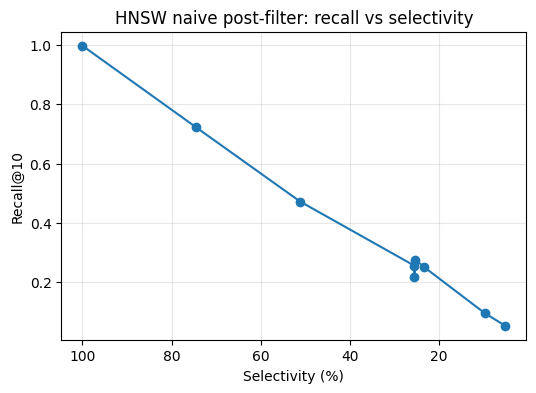

In [11]:
import matplotlib.pyplot as plt
plot_df = results_df.sort_values("selectivity")
plt.figure(figsize=(6,4))
plt.plot(plot_df["selectivity"], plot_df["recall_at_10"], marker="o")
plt.xlabel("Selectivity (%)"); plt.ylabel("Recall@10")
plt.title("HNSW naive post-filter: recall vs selectivity")
plt.gca().invert_xaxis()
plt.grid(True, alpha=0.3)
plt.show()
